# Flickr30k Image Captioning with Visual Attention

This notebook implements a high-complexity **Show, Attend and Tell** visual captioning architecture on the **Flickr30k** dataset using PyTorch. It features:
- A **ResNet-50** CNN backbone acting as a spatial feature extractor.
- A **Bahdanau Attention** (Visual Attention) module that dynamically aligns words to different spatial regions of the image during generation.
- An **LSTM Cell** based Decoder with step-by-step unrolling.
- Implementations of **Greedy Search** and **Beam Search** decoding.
- Performance metric evaluation using **BLEU (1-4) scores**.
- Visual validation on random test images.

### Instructions to run on Kaggle:
1. Start a new notebook on Kaggle.
2. On the right-hand panel, click **Add input** and search for `flickr30k` or `flickr30k-images-ecce` and attach the dataset.
3. Set the Accelerator to **GPU T4** or **GPU P100** via Notebook options.
4. Run the cells sequentially.


In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hsankesara/flickr-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/hsankesara/flickr-image-dataset


In [14]:
import os
import random
import json
from collections import Counter
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import nltk
from nltk.translate.bleu_score import corpus_bleu

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models

nltk.download('punkt')

# --- CONFIGURATION ---
# Set the path to the Flickr30k dataset on Kaggle.
# Change this path to match your attached dataset if different!
# Set the path to the Flickr30k dataset.
if 'path' in locals() and os.path.exists(path):
    DATASET_DIR = os.path.join(path, 'flickr30k_images')
    if not os.path.exists(DATASET_DIR):
        DATASET_DIR = path
else:
    DATASET_DIR = '/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images'
IMAGES_DIR = os.path.join(DATASET_DIR, 'flickr30k_images', 'flickr30k_images')

# Check for alternative common paths just in case
if not os.path.exists(IMAGES_DIR):
    IMAGES_DIR = os.path.join(DATASET_DIR, 'flickr30k_images')
if not os.path.exists(IMAGES_DIR):
    IMAGES_DIR = '/kaggle/input/flickr-image-dataset/flickr30k_images/flickr30k_images'

CSV_PATH = os.path.join(DATASET_DIR, 'results.csv')
if not os.path.exists(CSV_PATH):
    CSV_PATH = '/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv'

# Hyperparameters
EMBED_SIZE = 256
HIDDEN_SIZE = 512
ATTENTION_DIM = 256
LEARNING_RATE = 1e-3
BATCH_SIZE = 64
NUM_EPOCHS = 10
VOCAB_THRESHOLD = 3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 1. Vocabulary Construction

The model needs to convert words into index tokens. We build a vocabulary using only the words that appear in the training split annotations above a frequency threshold.


In [15]:
class Vocabulary:
    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.words = []
        self.pad_val = '<pad>'
        self.end_val = '<end>'
        self.unk_val = '<unk>'
        
        self.add_word(self.pad_val)
        self.add_word(self.end_val)
        self.add_word(self.unk_val)

    def add_word(self, word):
        if word not in self.word2idx:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
            self.words.append(word)

    def __call__(self, word):
        return self.word2idx.get(word, self.word2idx[self.unk_val])

    def __len__(self):
        return len(self.word2idx)

def build_vocab_from_df(df, threshold=3):
    print('Building vocabulary from dataframe...')
    counter = Counter()
    for comment in tqdm(df['comment'], desc='Tokenizing'):
        tokens = nltk.word_tokenize(str(comment).lower())
        counter.update(tokens)

    vocab = Vocabulary()
    for word, count in counter.items():
        if count >= threshold:
            vocab.add_word(word)

    print(f'Vocabulary size: {len(vocab)}')
    return vocab


## 2. Dataset and Splits

We load the Flickr30k annotations `results.csv`, verify that each image exists, and split the dataset programmatically: **90% for training**, **5% for validation**, and **5% for testing**.


In [16]:
class Flickr30kDataset(Dataset):
    def __init__(self, root_dir, df, vocab, transform=None):
        self.root_dir = root_dir
        self.vocab = vocab
        self.transform = transform
        
        self.annotations = []
        for idx, row in df.iterrows():
            img_name = str(row['image_name']).strip()
            comment = str(row['comment']).strip()
            self.annotations.append((img_name, comment))

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        img_id, caption = self.annotations[index]
        img_path = os.path.join(self.root_dir, img_id)
        
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        tokens = nltk.word_tokenize(caption.lower())
        caption_indices = [self.vocab(token) for token in tokens]
        caption_indices.append(self.vocab(self.vocab.end_val))

        return image, torch.tensor(caption_indices)

class CollateFn:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        batch.sort(key=lambda x: len(x[1]), reverse=True)
        images = [item[0] for item in batch]
        captions = [item[1] for item in batch]

        images = torch.stack(images, dim=0)
        lengths = [len(cap) for cap in captions]
        
        padded_captions = torch.zeros(len(captions), max(lengths)).long().fill_(self.pad_idx)
        for i, cap in enumerate(captions):
            padded_captions[i, :lengths[i]] = cap

        return images, padded_captions, torch.tensor(lengths)

# Load annotations and perform programmatic split
print(f'Loading annotations from {CSV_PATH}...')
df = pd.read_csv(CSV_PATH, sep='|', on_bad_lines='skip')
df.columns = df.columns.str.strip()
df = df.dropna(subset=['image_name', 'comment'])

# Filter rows where images do not exist
print('Verifying image existences...')
existing_images = set(os.listdir(IMAGES_DIR))
df = df[df['image_name'].isin(existing_images)].reset_index(drop=True)
print(f'Total verified image-caption pairs: {len(df)}')

unique_imgs = sorted(df['image_name'].unique())
random.seed(42)
random.shuffle(unique_imgs)

n_imgs = len(unique_imgs)
train_split = int(n_imgs * 0.90)
val_split = int(n_imgs * 0.95)

train_imgs = set(unique_imgs[:train_split])
val_imgs = set(unique_imgs[train_split:val_split])
test_imgs = set(unique_imgs[val_split:])


train_df = df[df['image_name'].isin(train_imgs)].reset_index(drop=True)
val_df = df[df['image_name'].isin(val_imgs)].reset_index(drop=True)
test_df = df[df['image_name'].isin(test_imgs)].reset_index(drop=True)

print(f'Split sizes: Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}')

# Build Vocab
vocab = build_vocab_from_df(train_df, threshold=VOCAB_THRESHOLD)
pad_idx = vocab(vocab.pad_val)

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

collate_fn = CollateFn(pad_idx)

# Data Loaders
train_loader = DataLoader(
    dataset=Flickr30kDataset(IMAGES_DIR, train_df, vocab, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    dataset=Flickr30kDataset(IMAGES_DIR, val_df, vocab, val_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

Loading annotations from /kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv...
Verifying image existences...
Total verified image-caption pairs: 158914
Split sizes: Train=143019 | Val=7945 | Test=7950
Building vocabulary from dataframe...


Tokenizing: 100%|██████████| 143019/143019 [00:07<00:00, 20028.94it/s]


Vocabulary size: 9647


## 3. Show, Attend and Tell Model Architecture

Visual Attention allows the LSTM cell to selectively focus on specific parts of the image (e.g. 14x14 grid) at each step of text generation. We project the encoder features and hidden state to compute dynamic weights.


In [ ]:
class EncoderCNN_Attention(nn.Module):
    def __init__(self, encoded_image_size=14, train_cnn=False):
        super(EncoderCNN_Attention, self).__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        self.train_cnn = train_cnn
        for param in self.resnet.parameters():
            param.requires_grad = train_cnn

    def forward(self, images):
        with torch.set_grad_enabled(self.train_cnn):
            features = self.resnet(images)
            features = self.adaptive_pool(features)
            features = features.permute(0, 2, 3, 1)
            features = features.view(features.size(0), -1, features.size(3))
        return features

class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att = self.full_att(torch.tanh(att1 + att2.unsqueeze(1))).squeeze(2)
        alpha = self.softmax(att)
        return alpha

class DecoderRNN_Attention(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, encoder_dim=2048, attention_dim=256):
        super(DecoderRNN_Attention, self).__init__()
        self.vocab_size = vocab_size
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm_cell = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.init_img_embed = nn.Linear(encoder_dim, embed_size)
        
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1)
        
        mean_encoder_out = encoder_out.mean(dim=1)
        h = torch.tanh(self.init_h(mean_encoder_out))
        c = torch.tanh(self.init_c(mean_encoder_out))
        img_embed = torch.tanh(self.init_img_embed(mean_encoder_out))
        
        embeddings = self.embed(captions)
        outputs = torch.zeros(batch_size, seq_len, self.vocab_size).to(encoder_out.device)
        
        for t in range(seq_len):
            if t == 0:
                current_embed = img_embed
            else:
                current_embed = embeddings[:, t-1, :]
            
            alpha = self.attention(encoder_out, h)
            context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
            
            lstm_input = torch.cat([current_embed, context], dim=1)
            h, c = self.lstm_cell(self.dropout(lstm_input), (h, c))
            preds = self.fc(self.dropout(h))
            outputs[:, t, :] = preds
            
        return outputs

class ShowAttendAndTell(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, encoder_dim=2048, attention_dim=256, train_cnn=False):
        super(ShowAttendAndTell, self).__init__()
        self.encoder = EncoderCNN_Attention(train_cnn=train_cnn)
        self.decoder = DecoderRNN_Attention(
            embed_size=embed_size,
            hidden_size=hidden_size,
            vocab_size=vocab_size,
            encoder_dim=encoder_dim,
            attention_dim=attention_dim
        )

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs


## 4. Model Training

We train the model using Cross-Entropy loss. Since the encoder is frozen, we only optimize the attention mechanism and decoder parameters. Best weights are saved to `checkpoints/best.pth`.

Starting training on cuda for 10 epochs...


Epoch 1/10 [Train]: 100%|██████████| 2235/2235 [26:27<00:00,  1.41it/s]


Epoch [1/10] - Train Loss: 3.6690 | Val Loss: 3.0885
New best model saved with Val Loss: 3.0885


Epoch 2/10 [Train]: 100%|██████████| 2235/2235 [26:24<00:00,  1.41it/s]


Epoch [2/10] - Train Loss: 3.1716 | Val Loss: 2.9275
New best model saved with Val Loss: 2.9275


...

Epoch [8/10] - Train Loss: 2.7343 | Val Loss: 2.7933
New best model saved with Val Loss: 2.7933


Epoch 9/10 [Train]: 100%|██████████| 2235/2235 [26:28<00:00,  1.41it/s]


Epoch [9/10] - Train Loss: 2.7046 | Val Loss: 2.7895
New best model saved with Val Loss: 2.7895


Epoch 10/10 [Train]: 100%|██████████| 2235/2235 [26:27<00:00,  1.41it/s]


Epoch [10/10] - Train Loss: 2.6796 | Val Loss: 2.7913


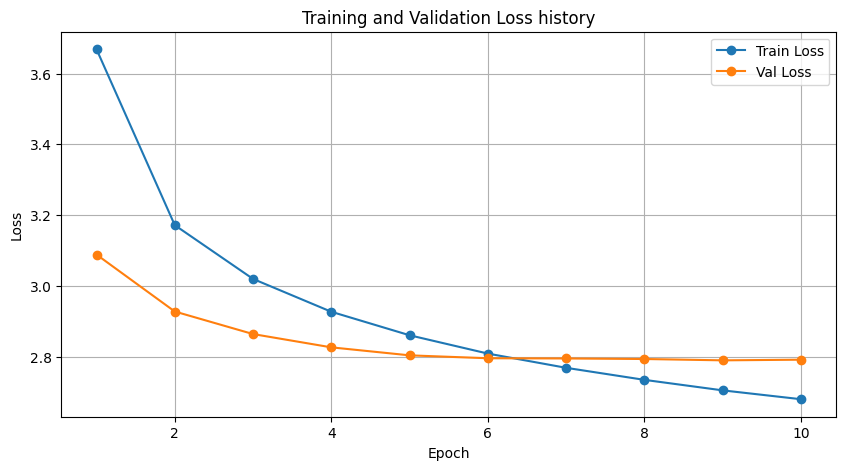

In [18]:
model = ShowAttendAndTell(
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    vocab_size=len(vocab),
    attention_dim=ATTENTION_DIM,
    train_cnn=False
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')

os.makedirs('checkpoints', exist_ok=True)

print(f'Starting training on {DEVICE} for {NUM_EPOCHS} epochs...')
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    train_steps = 0
    
    for images, captions, lengths in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [Train]'):
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images, captions)
        loss = criterion(outputs.view(-1, len(vocab)), captions.view(-1))
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_steps += 1
        
    avg_train_loss = train_loss / train_steps
    
    model.eval()
    val_loss = 0.0
    val_steps = 0
    with torch.no_grad():
        for images, captions, lengths in val_loader:
            images = images.to(DEVICE)
            captions = captions.to(DEVICE)
            
            outputs = model(images, captions)
            loss = criterion(outputs.view(-1, len(vocab)), captions.view(-1))
            val_loss += loss.item()
            val_steps += 1
            
    avg_val_loss = val_loss / val_steps
    print(f'Epoch [{epoch}/{NUM_EPOCHS}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'embed_size': EMBED_SIZE,
        'hidden_size': HIDDEN_SIZE,
        'vocab_size': len(vocab),
        'attention_dim': ATTENTION_DIM
    }
    
    torch.save(checkpoint, 'checkpoints/latest.pth')
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(checkpoint, 'checkpoints/best.pth')
        print(f'New best model saved with Val Loss: {avg_val_loss:.4f}')

# Plotting Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), history['train_loss'], label='Train Loss', marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), history['val_loss'], label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss history')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
plt.show()

## 5. Inference Search Algorithms

We define Greedy Search and Beam Search decoding strategies to translate visual features to caption sentences step-by-step.


In [19]:
def greedy_search_attention(model, image_tensor, vocab, max_length=20, device='cpu'):
    model.eval()
    predicted_words = []
    
    with torch.no_grad():
        encoder_out = model.encoder(image_tensor.to(device))
        mean_encoder_out = encoder_out.mean(dim=1)
        h = torch.tanh(model.decoder.init_h(mean_encoder_out))
        c = torch.tanh(model.decoder.init_c(mean_encoder_out))
        current_embed = torch.tanh(model.decoder.init_img_embed(mean_encoder_out))
        
        for t in range(max_length):
            alpha = model.decoder.attention(encoder_out, h)
            context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
            
            lstm_input = torch.cat([current_embed, context], dim=1)
            h, c = model.decoder.lstm_cell(lstm_input, (h, c))
            logits = model.decoder.fc(h)
            predicted_idx = logits.argmax(dim=1).item()
            
            if predicted_idx == vocab(vocab.end_val):
                break
                
            word = vocab.idx2word.get(predicted_idx, vocab.unk_val)
            predicted_words.append(word)
            current_embed = model.decoder.embed(torch.tensor([[predicted_idx]]).to(device)).squeeze(1)
            
    return ' '.join(predicted_words)

def beam_search_attention(model, image_tensor, vocab, beam_width=3, max_length=20, device='cpu'):
    model.eval()
    with torch.no_grad():
        encoder_out = model.encoder(image_tensor.to(device))
        mean_encoder_out = encoder_out.mean(dim=1)
        h = torch.tanh(model.decoder.init_h(mean_encoder_out))
        c = torch.tanh(model.decoder.init_c(mean_encoder_out))
        current_embed = torch.tanh(model.decoder.init_img_embed(mean_encoder_out))
        
        alpha = model.decoder.attention(encoder_out, h)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        
        lstm_input = torch.cat([current_embed, context], dim=1)
        h, c = model.decoder.lstm_cell(lstm_input, (h, c))
        logits = model.decoder.fc(h)
        log_probs = torch.log_softmax(logits, dim=1)
        
        top_log_probs, top_indices = log_probs.topk(beam_width, dim=1)
        
        beams = []
        for i in range(beam_width):
            beams.append((
                top_log_probs[0, i].item(),
                [top_indices[0, i].item()],
                (h, c)
            ))
            
        for _ in range(max_length - 1):
            candidates = []
            for score, indices, (h_prev, c_prev) in beams:
                if indices[-1] == vocab(vocab.end_val):
                    candidates.append((score, indices, (h_prev, c_prev)))
                    continue
                
                last_word = indices[-1]
                current_embed = model.decoder.embed(torch.tensor([[last_word]]).to(device)).squeeze(1)
                
                alpha = model.decoder.attention(encoder_out, h_prev)
                context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
                
                lstm_input = torch.cat([current_embed, context], dim=1)
                h_new, c_new = model.decoder.lstm_cell(lstm_input, (h_prev, c_prev))
                logits = model.decoder.fc(h_new)
                log_probs = torch.log_softmax(logits, dim=1)
                
                top_log_probs, top_indices = log_probs.topk(beam_width, dim=1)
                for i in range(beam_width):
                    candidates.append((
                        score + top_log_probs[0, i].item(),
                        indices + [top_indices[0, i].item()],
                        (h_new, c_new)
                    ))
            
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_width]
            
            all_ended = all(indices[-1] == vocab(vocab.end_val) for _, indices, _ in beams)
            if all_ended:
                break
                
        best_score, best_indices, _ = beams[0]
        caption_words = []
        for idx in best_indices:
            if idx == vocab(vocab.end_val):
                break
            caption_words.append(vocab.idx2word.get(idx, vocab.unk_val))
            
        return ' '.join(caption_words)


## 6. Model Evaluation

We select the first 100 test split images to run BLEU evaluation using `corpus_bleu` from `nltk.translate.bleu_score`.


In [20]:
print('Starting BLEU evaluation on test set...')
# Group test set captions by image_name
test_image_captions = {}
for idx, row in test_df.iterrows():
    img_name = row['image_name']
    comment = row['comment']
    if img_name not in test_image_captions:
        test_image_captions[img_name] = []
    test_image_captions[img_name].append(comment)

# Pick a subset of 100 test images for speed
test_images_subset = sorted(list(test_image_captions.keys()))[:100]

references = []
hypotheses_greedy = []
hypotheses_beam = []

model.eval()
with torch.no_grad():
    for img_name in tqdm(test_images_subset, desc='Evaluating'):
        img_path = os.path.join(IMAGES_DIR, img_name)
        img = Image.open(img_path).convert('RGB')
        img_tensor = val_transform(img).unsqueeze(0).to(DEVICE)
        
        greedy_cap = greedy_search_attention(model, img_tensor, vocab, max_length=20, device=DEVICE)
        beam_cap = beam_search_attention(model, img_tensor, vocab, beam_width=3, max_length=20, device=DEVICE)
        
        hyp_greedy_tokens = nltk.word_tokenize(greedy_cap.lower())
        hyp_beam_tokens = nltk.word_tokenize(beam_cap.lower())
        
        hypotheses_greedy.append(hyp_greedy_tokens)
        hypotheses_beam.append(hyp_beam_tokens)
        
        img_refs = test_image_captions[img_name]
        ref_tokens_list = [nltk.word_tokenize(ref.lower()) for ref in img_refs]
        references.append(ref_tokens_list)

print('\n--- Greedy Decoding BLEU ---')
print(f'BLEU-1: {corpus_bleu(references, hypotheses_greedy, weights=(1.0, 0, 0, 0)) * 100:.2f}')
print(f'BLEU-2: {corpus_bleu(references, hypotheses_greedy, weights=(0.5, 0.5, 0, 0)) * 100:.2f}')
print(f'BLEU-3: {corpus_bleu(references, hypotheses_greedy, weights=(0.33, 0.33, 0.33, 0)) * 100:.2f}')
print(f'BLEU-4: {corpus_bleu(references, hypotheses_greedy, weights=(0.25, 0.25, 0.25, 0.25)) * 100:.2f}')

print('\n--- Beam Search Decoding (Width=3) BLEU ---')
print(f'BLEU-1: {corpus_bleu(references, hypotheses_beam, weights=(1.0, 0, 0, 0)) * 100:.2f}')
print(f'BLEU-2: {corpus_bleu(references, hypotheses_beam, weights=(0.5, 0.5, 0, 0)) * 100:.2f}')
print(f'BLEU-3: {corpus_bleu(references, hypotheses_beam, weights=(0.33, 0.33, 0.33, 0)) * 100:.2f}')
print(f'BLEU-4: {corpus_bleu(references, hypotheses_beam, weights=(0.25, 0.25, 0.25, 0.25)) * 100:.2f}')


Starting BLEU evaluation on test set...


Evaluating: 100%|██████████| 100/100 [00:06<00:00, 14.73it/s]



--- Greedy Decoding BLEU ---
BLEU-1: 64.89
BLEU-2: 45.35
BLEU-3: 31.43
BLEU-4: 21.60

--- Beam Search Decoding (Width=3) BLEU ---
BLEU-1: 67.48
BLEU-2: 47.09
BLEU-3: 33.05
BLEU-4: 22.97


## 7. Sample Predictions Visualization

We select 3 random test images, generate their captions, and plot them along with reference annotations.


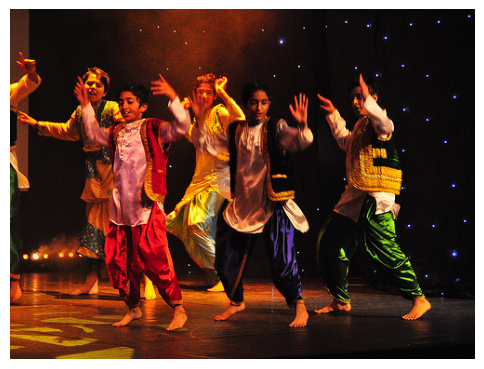

Image: 4097650560.jpg
Greedy Generated: a group of people are dancing in a dance studio .
Beam Generated: a group of people are dancing in a parade .
Ground Truth Reference Captions:
-  A young Indian dance troupe performing on stage during a local talent competition .
-  A group of Young ethnic kids performing a dance in traditional colorful outfits .
-  A young group of people in bright colorful clothes dance on stage .
-  A group is dancing with no shoes , with lights in the background .
-  During a scene in a play that is set at night , children dance .



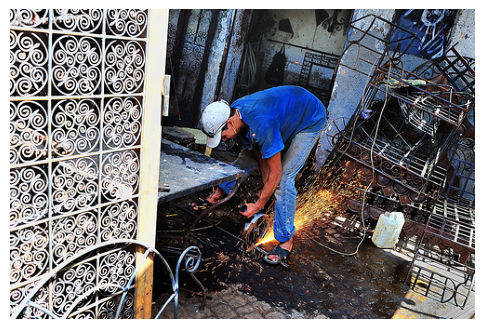

Image: 4904199439.jpg
Greedy Generated: a man in a blue shirt is working on a piece of metal .
Beam Generated: a man in a blue shirt is working on a construction project .
Ground Truth Reference Captions:
-  A man working with metals using welding or grinding tools .
-  A man in a blue shirt is cutting metal .
-  A man cutting metal with a tool .
-  Sparks fly as a man welds steel .
-  A man working in a dirty area .



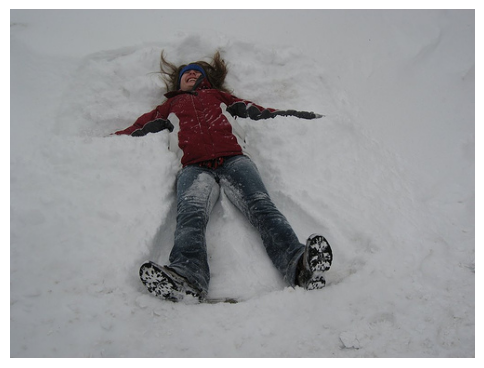

Image: 2045127186.jpg
Greedy Generated: a young girl in a red jacket is skiing down a snowy hill .
Beam Generated: a man in a red jacket is snowboarding down a snowy hill .
Ground Truth Reference Captions:
-  A young child in a red jacket and jeans lays in the snow to make a snow angel .
-  Girl in a red coat , blue head wrap and jeans is making a snow angel .
-  The young girl makes a wonderful snow angel on the ground .
-  A girl plays in the snow by making a snow angel .
-  A girl in a red coat making a snow angel .



In [21]:
def visualize_predictions(num_samples=3):
    model.eval()
    test_unique_imgs = sorted(list(test_image_captions.keys()))
    samples = random.sample(test_unique_imgs, min(num_samples, len(test_unique_imgs)))
    
    for img_name in samples:
        img_path = os.path.join(IMAGES_DIR, img_name)
        img = Image.open(img_path).convert('RGB')
        img_tensor = val_transform(img).unsqueeze(0).to(DEVICE)
        
        greedy_cap = greedy_search_attention(model, img_tensor, vocab, max_length=20, device=DEVICE)
        beam_cap = beam_search_attention(model, img_tensor, vocab, beam_width=3, max_length=20, device=DEVICE)
        
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        
        print(f'Image: {img_name}')
        print(f'Greedy Generated: {greedy_cap}')
        print(f'Beam Generated: {beam_cap}')
        print('Ground Truth Reference Captions:')
        for ref in test_image_captions[img_name]:
            print(f'- {ref}')
        print('='*60 + '\n')

visualize_predictions(3)


In [22]:
!zip -r checkpoints.zip /kaggle/working

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/checkpoints/ (stored 0%)
updating: kaggle/working/checkpoints/best.pth (deflated 7%)
updating: kaggle/working/checkpoints/latest.pth (deflated 7%)
updating: kaggle/working/.virtual_documents/ (stored 0%)
updating: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 74%)
updating: kaggle/working/loss_plot.png (deflated 10%)
updating: kaggle/working/.ipynb_checkpoints/ (stored 0%)
